
Loaded mof_extraction.csv
Total rows: 23383

PDF availability counts
Have value in main_pdf: 21825
Have value in si_pdf: 19086
Have both: 18056
Only main not si: 3769
Only si not main: 1030
Neither: 528
After dropping rows with neither main_pdf nor si_pdf, rows left: 22855

article_trial_or_failure filter
Rows total before filter: 22855
Dropping rows where 'article_trial_or_failure' is neither yes nor no: 1052
Rows left: 21803

Drop rows with required empties
Dropping rows where any of ['metal_1', 'linker_1', 'solvent_main', 'solvent_main_abbr'] is empty: 744
Rows left: 21059

crystal_code cleaned
crystal_code changed: 16109
linker_1 trailing parens removed: 2204
linker_2 trailing parens removed: 15661
linker_3 trailing parens removed: 20960

temperature_c cleaning
Rows to drop due to temperature_c_text containing microwave or evaporation or slow: 371
Dropping rows with empty temperature_c after filling: 891
Rows left after temperature filters: 19797
metal_1: replaced ' × ' with '·' i

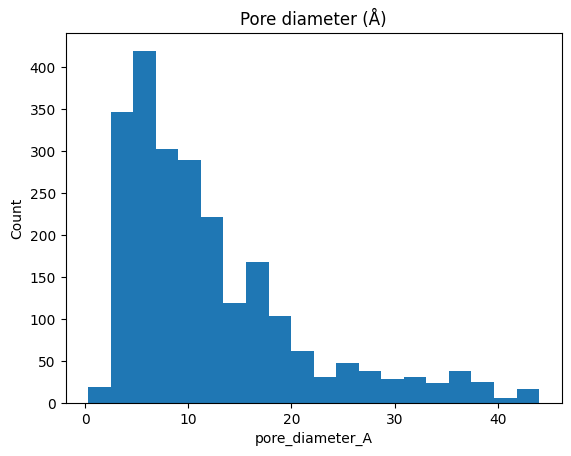


BET surface area (m²/g) distribution
BET_surface_area_m2g: numeric non empty count = 6064


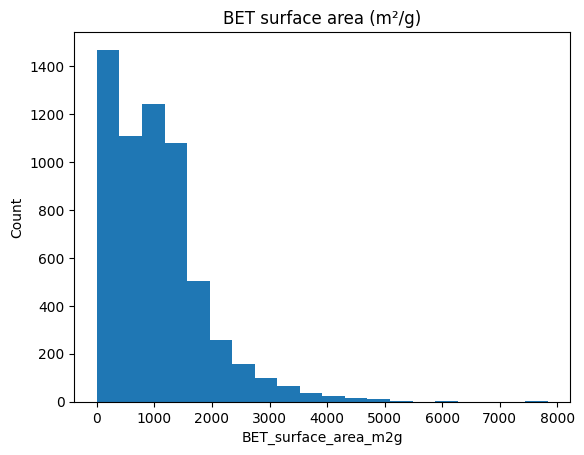


TGA decomposition temp (°C) distribution
tga_decomposition_temp_c: numeric non empty count = 6824


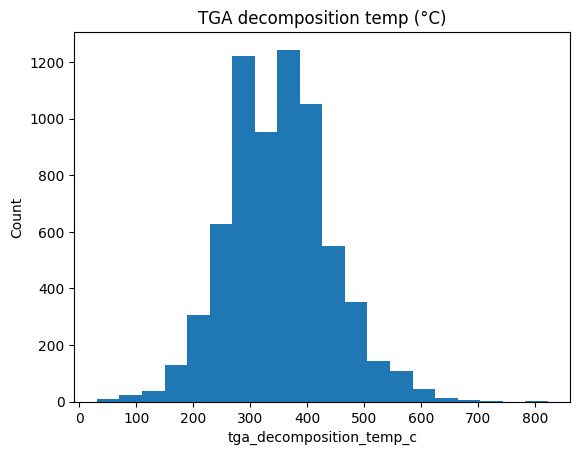


air_stable counts
yes: 1686
no: 171
not_reported: 14599
empty: 0
Top 10 values:
not_reported    14599
nan              3341
yes              1686
no                171

water_stable counts
yes: 1819
no: 468
not_reported: 14255
empty: 0
Top 10 values:
not_reported    14255
nan              3255
yes              1819
no                468

Wrote cleaned CSV to mof_extraction_1.csv


In [6]:
# Single-cell notebook to clean `mof_extraction.csv` and write `mof_extraction_1.csv`
# Prints required stats and plots simple distributions.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

# ---------- helpers ----------
def is_filled(x):
    if x is None:
        return False
    if isinstance(x, float) and np.isnan(x):
        return False
    s = str(x).strip()
    return s != "" and s.lower() not in {"nan", "none"}

def filled_series(s):
    return s.apply(is_filled)

def count_changes(before, after):
    return int((before.astype(str) != after.astype(str)).sum())

def print_header(msg):
    print("\n" + "=" * 80)
    print(msg)
    print("=" * 80)

def safe_lower(x):
    try:
        return str(x).strip().lower()
    except Exception:
        return ""

def strip_trailing_parens(val, keep_when="(anhydrous)"):
    """Remove a trailing ' ( ... )' only if it is not the allowed exception.
       If the trailing parens looks like a formula, keep only the inside.
       Returns new_val, changed_flag
    """
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    m = re.search(r"\s\(([^)]*)\)\s*$", s)
    if not m:
        return s, False
    inside = m.group(1).strip()
    if keep_when and s.endswith(f" {keep_when}"):
        return s, False
    # If inside looks like a formula, prefer the inside (e.g., '... (Ti(iPrO)4)' -> 'Ti(iPrO)4')
    if re.fullmatch(r"[A-Za-z0-9·\[\]\(\)]+", inside):
        return inside, True
    # Otherwise remove the whole trailing parenthetical
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def remove_linker_trailing_parens(val):
    """For linker names like 'salicylic acid (H2L1)' remove trailing ' (H2L1)'"""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    new_s = re.sub(r"\s\([^)]*\)\s*$", "", s)
    return new_s, new_s != s

def normalize_x_to_middle_dot(s):
    if not is_filled(s):
        return s, False
    new_s = str(s).replace(" × ", "·")
    return new_s, new_s != s

def extract_digits_after_ccdc(val):
    """For crystal_code: if contains 'CCDC', keep the digits; else if mixed, keep digits only."""
    if not is_filled(val):
        return val, False
    s = str(val).strip()
    if "CCDC" in s.upper():
        digits = "".join(re.findall(r"\d+", s))
        return digits, s != digits
    if re.search(r"[A-Za-z]", s):
        digits = "".join(re.findall(r"\d+", s))
        return (digits if digits != "" else s), digits != s
    return s, False

def coerce_numeric(series):
    return pd.to_numeric(series, errors="coerce")

# ---------- read ----------
in_path = Path("mof_extraction.csv")
if not in_path.exists():
    raise FileNotFoundError("mof_extraction.csv not found in the current folder")

# load as strings to avoid unintended type casting
df = pd.read_csv(in_path, dtype=str, encoding="utf-8")
print_header(f"Loaded {in_path.name}")
print(f"Total rows: {len(df)}")

# ---------- 1) main_pdf / si_pdf presence stats ----------
for col in ["main_pdf", "si_pdf"]:
    if col not in df.columns:
        df[col] = np.nan

has_main = filled_series(df["main_pdf"])
has_si = filled_series(df["si_pdf"])

both = has_main & has_si
only_main = has_main & ~has_si
only_si = ~has_main & has_si
neither = ~has_main & ~has_si

print_header("PDF availability counts")
print(f"Have value in main_pdf: {int(has_main.sum())}")
print(f"Have value in si_pdf: {int(has_si.sum())}")
print(f"Have both: {int(both.sum())}")
print(f"Only main not si: {int(only_main.sum())}")
print(f"Only si not main: {int(only_si.sum())}")
print(f"Neither: {int(neither.sum())}")

# drop neither
df = df[~neither].copy()
print(f"After dropping rows with neither main_pdf nor si_pdf, rows left: {len(df)}")

# ---------- 2) article_trial_or_failure filtering ----------
col_atof = "article_trial_or_failure"
if col_atof not in df.columns:
    df[col_atof] = np.nan

valnorm = df[col_atof].apply(safe_lower)
keep_atof = valnorm.isin({"yes", "no"})
print_header("article_trial_or_failure filter")
print(f"Rows total before filter: {len(df)}")
print(f"Dropping rows where '{col_atof}' is neither yes nor no: {int((~keep_atof).sum())}")
df = df[keep_atof].copy()
print(f"Rows left: {len(df)}")

# ---------- 3) drop required empties ----------
required_cols = ["metal_1", "linker_1", "solvent_main", "solvent_main_abbr"]
for c in required_cols:
    if c not in df.columns:
        df[c] = np.nan

mask_required = filled_series(df["metal_1"]) & filled_series(df["linker_1"]) & filled_series(df["solvent_main"]) & filled_series(df["solvent_main_abbr"])
print_header("Drop rows with required empties")
print(f"Dropping rows where any of {required_cols} is empty: {int((~mask_required).sum())}")
df = df[mask_required].copy()
print(f"Rows left: {len(df)}")

# ---------- 4) light cleaning ----------
# 4a) crystal_code
if "crystal_code" not in df.columns:
    df["crystal_code"] = np.nan
before = df["crystal_code"].fillna("")
df["crystal_code"], _flags = zip(*df["crystal_code"].apply(extract_digits_after_ccdc))
df["crystal_code"] = pd.Series(df["crystal_code"]).astype(str).str.strip()
print_header("crystal_code cleaned")
print(f"crystal_code changed: {count_changes(before, df['crystal_code'])}")

# 4b) linker columns: remove trailing parenthetical
for lk in ["linker_1", "linker_2", "linker_3"]:
    if lk in df.columns:
        before = df[lk].fillna("")
        df[lk], _flags = zip(*df[lk].apply(remove_linker_trailing_parens))
        df[lk] = pd.Series(df[lk]).astype(str).str.strip()
        print(f"{lk} trailing parens removed: {count_changes(before, df[lk])}")

# 4c) temperature handling
for col in ["temperature_c", "temperature_c_text"]:
    if col not in df.columns:
        df[col] = np.nan

txt = df["temperature_c_text"].astype(str)
needs_25 = (~filled_series(df["temperature_c"])) & (
    txt.str.contains(r"\bRT\b", case=True, na=False) | txt.str.contains("room temperature", case=False, na=False)
)
df.loc[needs_25, "temperature_c"] = "25"

drop_temp_text = txt.str.contains("microwave", case=False, na=False) | \
                 txt.str.contains("evaporation", case=False, na=False) | \
                 txt.str.contains("slow", case=False, na=False)
print_header("temperature_c cleaning")
print(f"Rows to drop due to temperature_c_text containing microwave or evaporation or slow: {int(drop_temp_text.sum())}")
df = df[~drop_temp_text].copy()

still_empty_temp = ~filled_series(df["temperature_c"])
print(f"Dropping rows with empty temperature_c after filling: {int(still_empty_temp.sum())}")
df = df[~still_empty_temp].copy()
print(f"Rows left after temperature filters: {len(df)}")

# 4d) metals: replace ' × ' with '·' and strip trailing parens except ' (anhydrous)'
metal_cols = ["metal_1", "metal_2", "metal_3"]
for mc in metal_cols:
    if mc not in df.columns:
        df[mc] = np.nan

# normalize middle dot
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc], _flags = zip(*df[mc].apply(normalize_x_to_middle_dot))
    df[mc] = pd.Series(df[mc])
    print(f"{mc}: replaced ' × ' with '·' in {count_changes(before, df[mc].fillna(''))} rows")

# strip trailing parentheses with rule
for mc in metal_cols:
    before = df[mc].fillna("")
    new_vals = []
    changed_count = 0
    for v in df[mc]:
        nv, ch = strip_trailing_parens(v, keep_when="(anhydrous)")
        new_vals.append(nv)
        changed_count += 1 if ch else 0
    df[mc] = pd.Series(new_vals).astype(str).str.strip()
    print(f"{mc}: trailing parentheses handled in {changed_count} rows")

# 4e) metal standardization dictionary (to canonical like FeCl3·6H2O)
metal_map = {
    # Chlorides and oxychlorides
    "zrcl4": "ZrCl4",
    "zirconium tetrachloride": "ZrCl4",
    "zrocl2·8h2o": "ZrOCl2·8H2O",
    "zrocl2.8h2o": "ZrOCl2·8H2O",
    # Aluminum
    "alcl3·6h2o": "AlCl3·6H2O",
    "alcl3.6h2o": "AlCl3·6H2O",
    "aluminium nitrate nonahydrate": "Al(NO3)3·9H2O",
    # Iron
    "fecl3·6h2o": "FeCl3·6H2O",
    "iron(iii) chloride hexahydrate": "FeCl3·6H2O",
    "iron powder": "Fe",
    # Zinc
    "zinc nitrate hexahydrate": "Zn(NO3)2·6H2O",
    # Copper
    "cu(no3)2·h2o": "Cu(NO3)2·H2O",
    "cu(no3)2×h2o": "Cu(NO3)2·H2O",
    "copper(ii) nitrate dihydrate (2.5-hydrate)": "Cu(NO3)2·2.5H2O",
    # Indium
    "indium(iii) nitrate tetrahydrate-hemihydrate": "In(NO3)3·4.5H2O",
    # Rare earth hydroxides
    "gadolinium(iii) hydroxide": "Gd(OH)3",
    "dysprosium(iii) hydroxide": "Dy(OH)3",
    "holmium(iii) hydroxide": "Ho(OH)3",
    "erbium(iii) hydroxide": "Er(OH)3",
    # Titanium
    "tio(acac)2": "TiO(acac)2",
    "ti(i-propoxide)4": "Ti(iPrO)4",
    "ti(ipro)4": "Ti(iPrO)4",
    "tii(pro)4": "Ti(iPrO)4",
}

def canon_metal(val):
    if not is_filled(val):
        return val
    s = str(val).strip()
    s_norm = s.replace(" × ", "·")
    s_norm = re.sub(r"\s+", " ", s_norm).strip()
    key = s_norm.lower()
    if key in metal_map:
        return metal_map[key]
    # hydrate punctuation variant
    key2 = key.replace("·", ".")
    if key2 in metal_map:
        return metal_map[key2]
    return s_norm

for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].apply(canon_metal).astype(str).str.strip()
    print(f"{mc}: standardized entries changed: {count_changes(before, df[mc])}")

# final normalization of any stray ×
for mc in metal_cols:
    before = df[mc].fillna("")
    df[mc] = df[mc].str.replace(r"\s*×\s*", "·", regex=True)
    print(f"{mc}: final '×' to '·' normalization count: {count_changes(before, df[mc].fillna(''))}")

    
    # ---------- pore_diameter_A cleanup ----------
if "pore_diameter_A" in df.columns:
    pore_vals = pd.to_numeric(df["pore_diameter_A"], errors="coerce")
    mean_val = pore_vals.dropna().mean()
    if not np.isnan(mean_val):
        df.loc[pore_vals > 2 * mean_val, "pore_diameter_A"] = ""
    
# ---------- topology_code cleaning ----------
if "topology_code" not in df.columns:
    df["topology_code"] = np.nan

topo = df["topology_code"].fillna("").astype(str).str.strip()

# Identify which entries are not exactly three letters (A–Z)
invalid_mask = ~topo.str.match(r"^[A-Za-z]{3}$")

# Count and show representative invalid entries
invalid_examples = topo[invalid_mask].replace("", np.nan).dropna().unique()
print_header("topology_code cleanup")
print(f"Total rows checked: {len(df)}")
print(f"Entries with invalid (non-three-letter) topology_code: {invalid_mask.sum()}")

if len(invalid_examples) > 0:
    print("Examples of removed topology_code values:")
    print(", ".join(invalid_examples[:10]))
else:
    print("No invalid topology_code values found.")

# Set invalid ones to empty string
df.loc[invalid_mask, "topology_code"] = ""    
    
    
    
    
    
    
    
# ---------- 5) Summary tables ----------
print_header("Summary after cleaning and filtering")

if "doi" not in df.columns:
    df["doi"] = np.nan

papers_left = df["doi"].dropna().astype(str).str.strip().replace("", np.nan).dropna().nunique()
rows_left = len(df)
print(f"Papers left (unique doi): {papers_left}")
print(f"Rows left: {rows_left}")

yes_articles = df.loc[df[col_atof].str.strip().str.lower() == "yes", "doi"].dropna().astype(str).str.strip().nunique()
print(f"Articles with article_trial_or_failure == yes (unique doi): {yes_articles}")



    
    
def print_uniques_and_top(df, cols, title):
    print_header(title)
    for c in cols:
        if c in df.columns:
            series = df[c].dropna().astype(str).str.strip()
            series = series[series != ""]
            u = series.nunique()
            print(f"{c}: unique values = {u}")
            vc = series.value_counts().head(10)
            if len(vc) > 0:
                print("Top 10:")
                print(vc.to_string())
            else:
                print("Top 10: none")
        else:
            print(f"{c}: column not found")

print_uniques_and_top(df, ["metal_1", "metal_2", "metal_3"], "Unique metals")
print_uniques_and_top(df, ["linker_1", "linker_2", "linker_3"], "Unique linkers")
print_uniques_and_top(df, ["modulator_1", "modulator_2", "modulator_3"], "Unique modulators")
print_uniques_and_top(df, ["solvent_main_abbr"], "Unique solvent_main_abbr")
print_uniques_and_top(df, ["temperature_c"], "Unique temperature_c")
print_uniques_and_top(df, ["time_h"], "Unique time_h")
print_uniques_and_top(df, ["topology_code"], "Unique topology_code")

# Numeric distributions
def histogram_and_count(df, col, title):
    print_header(f"{title} distribution")
    series = df[col] if col in df.columns else pd.Series(dtype=str)
    nonempty = series.dropna().astype(str).str.strip()
    nonempty = nonempty[nonempty != ""]
    vals = pd.to_numeric(nonempty, errors="coerce")
    count_nonnull = int(vals.notna().sum())
    print(f"{col}: numeric non empty count = {count_nonnull}")
    if count_nonnull > 0:
        plt.figure()
        vals.dropna().astype(float).plot(kind="hist", bins=20, title=title)
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.show()
    return count_nonnull

_ = histogram_and_count(df, "pore_diameter_A", "Pore diameter (Å)")
_ = histogram_and_count(df, "BET_surface_area_m2g", "BET surface area (m²/g)")
_ = histogram_and_count(df, "tga_decomposition_temp_c", "TGA decomposition temp (°C)")

# Stability counts
def stability_counts(col):
    if col not in df.columns:
        print(f"{col}: column not found")
        return
    s = df[col].apply(safe_lower)
    s = s.replace("", np.nan)
    total_yes = int((s == "yes").sum())
    total_no = int((s == "no").sum())
    total_not_reported = int((s == "not_reported").sum())
    total_empty = int(s.isna().sum())
    print_header(f"{col} counts")
    print(f"yes: {total_yes}")
    print(f"no: {total_no}")
    print(f"not_reported: {total_not_reported}")
    print(f"empty: {total_empty}")
    vc = s.value_counts(dropna=False).head(10)
    print("Top 10 values:")
    print(vc.to_string())

stability_counts("air_stable")
stability_counts("water_stable")

# ---------- write ----------
out_path = in_path.with_name("mof_extraction_1.csv")

# Replace NaN with empty string before saving
df = df.fillna("")

# Use UTF-8 with BOM to preserve all special symbols like "·"
df.to_csv(out_path, index=False, encoding="utf-8-sig")

print_header(f"Wrote cleaned CSV to {out_path.name}")

